In [6]:
# Linear Regression 실습
# 집값에 대한 회귀모형
# X변수가 여러개인 Multiple Linear Regression

In [10]:
# 데이터 로딩

import pandas as pd
import numpy as np

df = pd.read_csv("./data/manhattan.csv")
df.head()

,rental_id,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood,borough
0,1545,2550,0.0,1,480,9,2.0,17,1,1,0,0,1,1,0,1,Upper East Side,Manhattan
1,2472,11500,2.0,2,2000,4,1.0,96,0,0,0,0,0,0,0,0,Greenwich Village,Manhattan
2,2919,4500,1.0,1,916,2,51.0,29,0,1,0,1,1,1,0,0,Midtown,Manhattan
3,2790,4795,1.0,1,975,3,8.0,31,0,0,0,1,1,1,0,1,Greenwich Village,Manhattan
4,3946,17500,2.0,2,4800,3,4.0,136,0,0,0,1,1,1,0,1,Soho,Manhattan


In [12]:
# 데이터 분할
# X데이터와 y데이터 분리하기
X = df.drop(['borough', 'neighborhood', 'rental_id', 'rent'], axis=1)
y = df[['rent']]

In [16]:
# train 데이터와 test 데이터 분리

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [18]:
# 모델 적합. 다중 회귀분석도 동일 모델 사용

from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

In [22]:
# 모델을 통한 예측
# 침실 1개, 욕실 1개, 크기 600sqft, 전철까지 16분, 1ㅊㅇ, 건물연식 8년, no fee, roodexk 없고,
# washer_dryer 있고, doorman 없고, 엘리베이터 없, dishwasher 있, patio있, gym 없는 곳 가격예측
# 대략 2800달러 나와야

In [24]:
X.columns

Index(['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor',
       'building_age_yrs', 'no_fee', 'has_roofdeck', 'has_washer_dryer',
       'has_doorman', 'has_elevator', 'has_dishwasher', 'has_patio',
       'has_gym'],
      dtype='object')

In [26]:
my_apt = [[1, 1, 600, 16, 1, 8, 1, 0, 1, 0, 0, 1, 1, 0]]

In [28]:
mlr.predict(my_apt)

C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[2843.21472973]])

In [30]:
# 예측값과 실제값 비교

y_pred = mlr.predict(X_test)

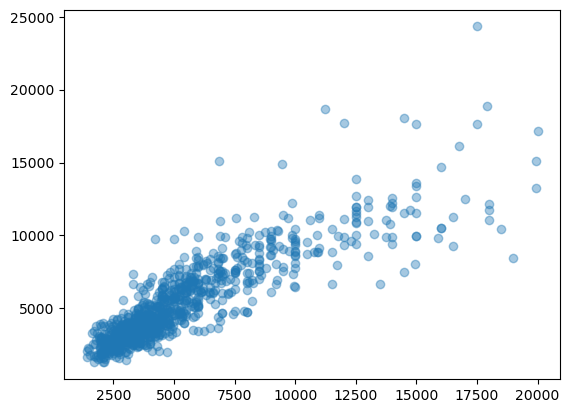

In [34]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha = 0.4)
plt.show()

#일치할수록 직선 형태이다

In [36]:
#회귀계수 계산
#각 변수의 기울기 (회귀계수) 확인

X.columns

Index(['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor',
       'building_age_yrs', 'no_fee', 'has_roofdeck', 'has_washer_dryer',
       'has_doorman', 'has_elevator', 'has_dishwasher', 'has_patio',
       'has_gym'],
      dtype='object')

In [38]:
# X변수들에 대한 기울기
print(mlr.coef_)

[[-3.37442440e+02  1.14772852e+03  5.02185987e+00 -1.30836256e+01
   2.39856476e+01 -7.13826956e+00 -9.63291469e+01  6.83771666e-01
   8.75351951e+01 -8.53967304e+01  1.38431646e+02 -9.02201864e-01
  -2.17216255e+02 -1.65474531e+01]]


In [40]:
# y절편
print(mlr.intercept_)

[-510.81634984]


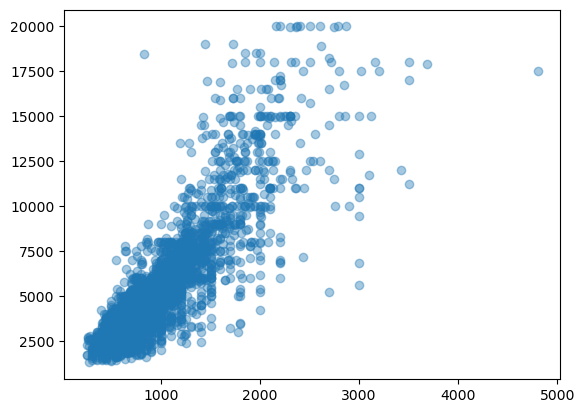

In [42]:
# 변수별 상관 확인 EDA

# 넓이와 집값 간 상관관계
plt.scatter(df[['size_sqft']], df[['rent']], alpha=0.4)
plt.show()

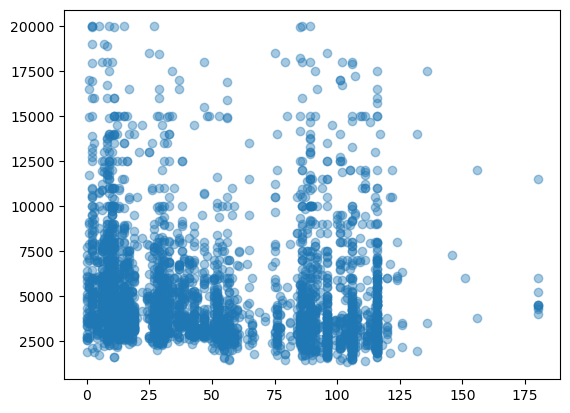

In [44]:
# 변수별 상관 확인
# 연식과 집값 간 상관관계
plt.scatter(df[['building_age_yrs']], df[['rent']], alpha=0.4)
plt.show()

In [46]:
# 성능평가

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [50]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

In [52]:
print("MAE : %.2f" %mae)
print("MSE : %.2f" %mse)
print("RMSE : %.2f" %rmse)
print("R2 : %.2f" %r2)

MAE : 951.32
MSE : 2271426.68
RMSE : 1507.13
R2 : 0.77
